<a href="https://colab.research.google.com/github/Roohikhan12/UI-Captioning/blob/main/Final_Fusion_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch==2.3.0 torchvision==0.18.0 --index-url https://download.pytorch.org/whl/cu121 -q

In [ ]:
import torch
print('PyTorch:', torch.__version__)
print('CUDA:', torch.version.cuda)
print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.3.0+cu121
CUDA: 12.1
GPU: Tesla P100-PCIE-16GB


In [ ]:
!pip install transformers rouge-score -q


In [ ]:

!pip install transformers rouge-score -q

import os
import gc
import random
import numpy as np
import pandas as pd
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from transformers import (
    ViTModel,
    GPT2LMHeadModel,
    GPT2Tokenizer,
    AutoImageProcessor
)

import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print(f'Free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB')

Device: cuda
GPU: Tesla P100-PCIE-16GB
Free: 16.8 GB


## 2. Paths — Set these for Kaggle

In [ ]:
IMAGE_DIR  = '/kaggle/input/datasets/roohikhan12/ui-captioning/rico_dataset_v0.1_semantic_annotations/rico_dataset_v0.1_semantic_annotations/semantic_annotations'
FUSION_CSV = '/kaggle/input/datasets/roohikhan12/ui-captioning/final_fusion_dataset.csv'
CKPT       = '/kaggle/working/fast_fusion_best.pth'

print('Images exist:', os.path.exists(IMAGE_DIR))
print('CSV exists  :', os.path.exists(FUSION_CSV))
print('Images found:', len([f for f in os.listdir(IMAGE_DIR) if f.endswith('.png')]))

Images exist: True
CSV exists  : True
Images found: 66261


## 3. Load Tokenizer & Feature Extractor

In [ ]:
# GPT2 tokenizer handles all text (captions + ui_text)
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

# ViT feature extractor handles image preprocessing
feature_extractor = AutoImageProcessor.from_pretrained('google/vit-base-patch16-224')
MAX_CAP_LEN  = 64
MAX_TEXT_LEN = 32

print('Tokenizer vocab size:', len(tokenizer))
print('EOS token id:', tokenizer.eos_token_id)

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Tokenizer vocab size: 50257
EOS token id: 50256


## 4. Load & Split Data

In [ ]:
df = pd.read_csv(FUSION_CSV)
df = df.dropna()
df = df[df['caption'].str.strip().str.len() > 10]
df = df.reset_index(drop=True)
print('Total rows:', len(df))

train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train: {len(train_df):,}')
print(f'Val  : {len(val_df):,}')
print(f'Test : {len(test_df):,}')

Total rows: 59676
Train: 47,740
Val  : 5,968
Test : 5,968


## 5. Dataset

In [ ]:
class FusionDataset(Dataset):
    def __init__(self, dataframe, image_dir, tokenizer, feature_extractor):
        self.df                = dataframe.reset_index(drop=True)
        self.image_dir         = image_dir
        self.tokenizer         = tokenizer
        self.feature_extractor = feature_extractor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Image
        image = Image.open(
            os.path.join(self.image_dir, row['image'])
        ).convert('RGB')
        pixel_values = self.feature_extractor(
            images=image, return_tensors='pt'
        ).pixel_values.squeeze(0)  # (3, 224, 224)

        # Caption — what the model must generate
        caption_enc = self.tokenizer(
            str(row['caption']),
            max_length=MAX_CAP_LEN,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        caption_ids      = caption_enc.input_ids.squeeze(0)
        caption_mask     = caption_enc.attention_mask.squeeze(0)

        # UI text — extra context
        ui_text_enc = self.tokenizer(
            str(row['ui_text']),
            max_length=MAX_TEXT_LEN,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        ui_text_ids  = ui_text_enc.input_ids.squeeze(0)
        ui_text_mask = ui_text_enc.attention_mask.squeeze(0)

        return {
            'pixel_values' : pixel_values,
            'caption_ids'  : caption_ids,
            'caption_mask' : caption_mask,
            'ui_text_ids'  : ui_text_ids,
            'ui_text_mask' : ui_text_mask,
        }


BATCH_SIZE = 8

train_dataset = FusionDataset(train_df, IMAGE_DIR, tokenizer, feature_extractor)
val_dataset   = FusionDataset(val_df,   IMAGE_DIR, tokenizer, feature_extractor)
test_dataset  = FusionDataset(test_df,  IMAGE_DIR, tokenizer, feature_extractor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader):,}')
print(f'Val   batches: {len(val_loader):,}')

# Sanity check
batch = next(iter(train_loader))
print('pixel_values:', batch['pixel_values'].shape)
print('caption_ids :', batch['caption_ids'].shape)
print('ui_text_ids :', batch['ui_text_ids'].shape)

Train batches: 5,968
Val   batches: 746
pixel_values: torch.Size([8, 3, 224, 224])
caption_ids : torch.Size([8, 64])
ui_text_ids : torch.Size([8, 32])


## 6. Model — ViT Encoder + GPT2 Decoder + UI Text Fusion

In [ ]:
class FastFusionModel(nn.Module):
    """
    Multimodal UI captioning model.

    Architecture:
        Image  -> ViT (frozen except last 2 layers) -> 768-d
        UIText -> GPT2 embedding mean pool           -> 768-d
        Fusion -> Linear(768+768, 768) -> feeds GPT2 as prefix
        GPT2   -> generates caption tokens
    """

    def __init__(self, tokenizer):
        super().__init__()

        # ---- Image Encoder (ViT) ----
        self.vit = ViTModel.from_pretrained('google/vit-base-patch16-224')
        # Freeze all ViT layers except last 2
        for name, param in self.vit.named_parameters():
            param.requires_grad = False
        for name, param in self.vit.named_parameters():
            if 'encoder.layer.10' in name or 'encoder.layer.11' in name or 'layernorm' in name:
                param.requires_grad = True

        # ---- Caption Decoder (GPT2) ----
        self.gpt2 = GPT2LMHeadModel.from_pretrained('gpt2')
        self.gpt2.resize_token_embeddings(len(tokenizer))
        # Freeze all GPT2 except last 2 transformer blocks
        for name, param in self.gpt2.named_parameters():
            param.requires_grad = False
        for name, param in self.gpt2.named_parameters():
            if 'h.10' in name or 'h.11' in name or 'ln_f' in name or 'lm_head' in name:
                param.requires_grad = True

        # ---- Fusion Projection ----
        # ViT CLS token = 768, GPT2 hidden = 768
        self.fusion_proj = nn.Sequential(
            nn.Linear(768 + 768, 768),
            nn.Tanh()
        )

        # UI text uses GPT2 embedding table for encoding
        self.ui_proj = nn.Linear(768, 768)

    def encode_image(self, pixel_values):
        """Returns CLS token from ViT: (B, 768)"""
        outputs = self.vit(pixel_values=pixel_values)
        return outputs.last_hidden_state[:, 0, :]  # CLS token

    def encode_ui_text(self, ui_text_ids, ui_text_mask):
        """Mean pool GPT2 embeddings of UI text: (B, 768)"""
        emb  = self.gpt2.transformer.wte(ui_text_ids)  # (B, T, 768)
        mask = ui_text_mask.unsqueeze(-1).float()       # (B, T, 1)
        return (emb * mask).sum(1) / mask.sum(1).clamp(min=1)  # (B, 768)

    def forward(self, pixel_values, caption_ids, caption_mask,
                ui_text_ids, ui_text_mask):

        # Encode image and UI text
        img_feat  = self.encode_image(pixel_values)                    # (B, 768)
        text_feat = self.encode_ui_text(ui_text_ids, ui_text_mask)     # (B, 768)

        # Fuse into a single prefix token
        fused = self.fusion_proj(
            torch.cat([img_feat, text_feat], dim=1)
        ).unsqueeze(1)  # (B, 1, 768)

        # Get GPT2 token embeddings for caption
        cap_emb = self.gpt2.transformer.wte(caption_ids)  # (B, T, 768)

        # Prepend fused prefix to caption embeddings
        inputs_embeds = torch.cat([fused, cap_emb], dim=1)  # (B, T+1, 768)

        # Extend attention mask
        prefix_mask   = torch.ones(caption_mask.shape[0], 1, device=device)
        extended_mask = torch.cat([prefix_mask, caption_mask.float()], dim=1)

        # Labels: -100 for prefix token (ignore), then caption ids
        labels = torch.cat([
            torch.full((caption_ids.shape[0], 1), -100, device=device, dtype=torch.long),
            caption_ids
        ], dim=1)
        # Ignore padding in loss
        labels[labels == tokenizer.pad_token_id] = -100

        outputs = self.gpt2(
            inputs_embeds=inputs_embeds,
            attention_mask=extended_mask,
            labels=labels
        )
        return outputs.loss

    @torch.no_grad()
    def generate_caption(self, pixel_values, ui_text_ids, ui_text_mask,
                         max_new_tokens=40):
        """Generate caption using greedy decoding."""
        self.eval()

        img_feat  = self.encode_image(pixel_values)
        text_feat = self.encode_ui_text(ui_text_ids, ui_text_mask)
        fused     = self.fusion_proj(
            torch.cat([img_feat, text_feat], dim=1)
        ).unsqueeze(1)  # (B, 1, 768)

        # Start with just the prefix
        generated = []
        past_key_values = None
        current_embeds  = fused
        attention_mask  = torch.ones(pixel_values.shape[0], 1, device=device)

        for _ in range(max_new_tokens):
            outputs = self.gpt2(
                inputs_embeds=current_embeds,
                attention_mask=attention_mask,
                past_key_values=past_key_values,
                use_cache=True
            )
            logits          = outputs.logits[:, -1, :]   # (B, vocab)
            past_key_values = outputs.past_key_values
            next_token      = logits.argmax(dim=-1)       # (B,)
            generated.append(next_token)

            # Stop if all sequences hit EOS
            if (next_token == tokenizer.eos_token_id).all():
                break

            current_embeds = self.gpt2.transformer.wte(next_token).unsqueeze(1)
            attention_mask = torch.cat([
                attention_mask,
                torch.ones(pixel_values.shape[0], 1, device=device)
            ], dim=1)

        generated = torch.stack(generated, dim=1)  # (B, T)
        return generated


gc.collect()
torch.cuda.empty_cache()

model = FastFusionModel(tokenizer).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total/1e6:.1f}M')
print(f'Trainable params: {trainable/1e6:.1f}M')
print(f'Free GPU memory : {torch.cuda.mem_get_info()[0]/1e9:.1f} GB')

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total params    : 212.6M
Trainable params: 30.2M
Free GPU memory : 15.8 GB


## 7. Training

In [ ]:
EPOCHS      = 5
LR          = 2e-5   # small LR for fine-tuning pretrained models
PATIENCE    = 2
ACCUM_STEPS = 4      # effective batch = 8 * 4 = 32

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=0.01
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=1
)

train_losses, val_losses = [], []
best_val_loss = float('inf')
no_improve    = 0

for epoch in range(1, EPOCHS + 1):

    # ---- Train ----
    model.train()
    total_train = 0
    optimizer.zero_grad()

    loop = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS} [Train]')
    for batch_idx, batch in enumerate(loop):
        pixel_values = batch['pixel_values'].to(device)
        caption_ids  = batch['caption_ids'].to(device)
        caption_mask = batch['caption_mask'].to(device)
        ui_text_ids  = batch['ui_text_ids'].to(device)
        ui_text_mask = batch['ui_text_mask'].to(device)

        loss = model(
            pixel_values, caption_ids, caption_mask,
            ui_text_ids, ui_text_mask
        ) / ACCUM_STEPS

        loss.backward()

        if (batch_idx + 1) % ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0
            )
            optimizer.step()
            optimizer.zero_grad()

        total_train += loss.item() * ACCUM_STEPS
        loop.set_postfix(loss=f'{loss.item() * ACCUM_STEPS:.4f}')

        if batch_idx % 200 == 0:
            gc.collect()
            torch.cuda.empty_cache()

    avg_train = total_train / len(train_loader)
    train_losses.append(avg_train)

    # ---- Validate ----
    model.eval()
    total_val = 0

    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch['pixel_values'].to(device)
            caption_ids  = batch['caption_ids'].to(device)
            caption_mask = batch['caption_mask'].to(device)
            ui_text_ids  = batch['ui_text_ids'].to(device)
            ui_text_mask = batch['ui_text_mask'].to(device)

            loss = model(
                pixel_values, caption_ids, caption_mask,
                ui_text_ids, ui_text_mask
            )
            total_val += loss.item()

    avg_val = total_val / len(val_loader)
    val_losses.append(avg_val)
    scheduler.step(avg_val)

    print(f'Epoch {epoch:02d} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}')

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        no_improve    = 0
        torch.save(model.state_dict(), CKPT)
        print(f'  ✓ Best model saved (val_loss={best_val_loss:.4f})')
    else:
        no_improve += 1
        print(f'  No improvement ({no_improve}/{PATIENCE})')
        if no_improve >= PATIENCE:
            print('Early stopping.')
            break

print('Training complete.')

Epoch 1/5 [Train]: 100%|██████████| 5968/5968 [49:46<00:00,  2.00it/s, loss=3.7452] 


Epoch 01 | Train Loss: 3.9389 | Val Loss: 3.5074
  ✓ Best model saved (val_loss=3.5074)


Epoch 2/5 [Train]: 100%|██████████| 5968/5968 [48:29<00:00,  2.05it/s, loss=4.0975]


Epoch 02 | Train Loss: 3.6436 | Val Loss: 3.3945
  ✓ Best model saved (val_loss=3.3945)


Epoch 3/5 [Train]: 100%|██████████| 5968/5968 [49:50<00:00,  2.00it/s, loss=2.8293]


Epoch 03 | Train Loss: 3.5333 | Val Loss: 3.3135
  ✓ Best model saved (val_loss=3.3135)


Epoch 4/5 [Train]: 100%|██████████| 5968/5968 [49:01<00:00,  2.03it/s, loss=3.3209] 


Epoch 04 | Train Loss: 3.4533 | Val Loss: 3.2441
  ✓ Best model saved (val_loss=3.2441)


Epoch 5/5 [Train]: 100%|██████████| 5968/5968 [48:14<00:00,  2.06it/s, loss=3.0757]


Epoch 05 | Train Loss: 3.3882 | Val Loss: 3.1867
  ✓ Best model saved (val_loss=3.1867)
Training complete.


## 8. Training Curves

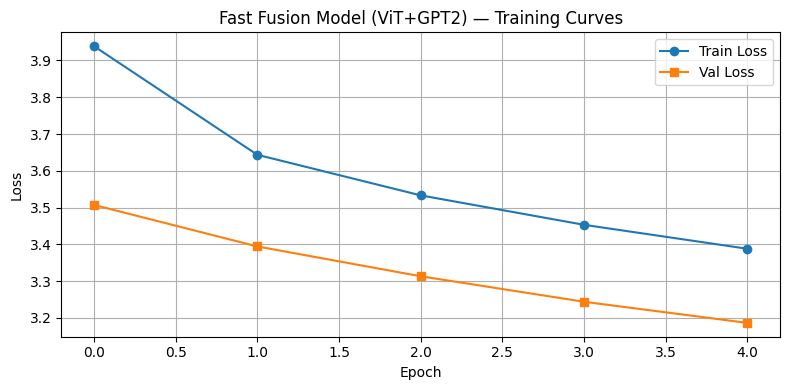

Saved: training_curves.png


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses,   label='Val Loss',   marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fast Fusion Model (ViT+GPT2) — Training Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()
print('Saved: training_curves.png')

## 9. Load Best Model & Qualitative Examples

In [ ]:
model.load_state_dict(torch.load(CKPT, map_location=device))
model.eval()
print('Best checkpoint loaded.')

print('\n=== Qualitative Examples ===')
for i in range(10):
    idx   = random.randint(0, len(test_dataset) - 1)
    batch = test_dataset[idx]

    pixel_values = batch['pixel_values'].unsqueeze(0).to(device)
    ui_text_ids  = batch['ui_text_ids'].unsqueeze(0).to(device)
    ui_text_mask = batch['ui_text_mask'].unsqueeze(0).to(device)
    caption_ids  = batch['caption_ids']

    # Ground truth
    gt_tokens = caption_ids[caption_ids != tokenizer.pad_token_id]
    gt = tokenizer.decode(gt_tokens, skip_special_tokens=True)

    # Prediction
    generated = model.generate_caption(
        pixel_values, ui_text_ids, ui_text_mask, max_new_tokens=40
    )
    pred = tokenizer.decode(generated[0], skip_special_tokens=True)

    print(f'\n--- Example {i+1} ---')
    print(f'Ground Truth : {gt}')
    print(f'Prediction   : {pred}')

Best checkpoint loaded.

=== Qualitative Examples ===

--- Example 1 ---
Ground Truth : A screen displaying Customizing beliefs, OK, Don't remind, Scroll to View, If you are using a different system of cognitive therapy and want the titles of the beliefs to be consistent with what you are using, you can change the titles here. 

 Since most systems use similar definitions but different titles, it is
Prediction   : A screen displaying Welcome to the app, Welcome to the app, Welcome to the app, Welcome to the app, Welcome to the app.

You can change the language of the app by tapping

--- Example 2 ---
Ground Truth : A screen displaying LIBRARY, STORE, Go to the Store and choose from your favorite books., Import Books to the Toshiba Book Place from your SD card directory..
Prediction   : A screen displaying My Account, My Account, My Account, My Account, My Account, My Account. containing buttons Sign in, Sign in with Facebook. with input fields for Facebook. containing buttons Sign

---

## 10. Full Evaluation — BLEU 1-4, ROUGE-L, Token Accuracy

In [ ]:
from rouge_score import rouge_scorer as rs_module

scorer     = rs_module.RougeScorer(['rougeL'], use_stemmer=False)
all_refs   = []
all_hyps   = []
rouge_list = []
tok_acc_list = []

model.eval()
print('Evaluating on full test set...')

for batch in tqdm(test_loader):
    pixel_values = batch['pixel_values'].to(device)
    ui_text_ids  = batch['ui_text_ids'].to(device)
    ui_text_mask = batch['ui_text_mask'].to(device)
    caption_ids  = batch['caption_ids']

    generated = model.generate_caption(
        pixel_values, ui_text_ids, ui_text_mask, max_new_tokens=40
    ).cpu()

    for i in range(len(caption_ids)):
        gt_tokens = caption_ids[i]
        gt_tokens = gt_tokens[gt_tokens != tokenizer.pad_token_id]
        gt   = tokenizer.decode(gt_tokens, skip_special_tokens=True).strip().split()

        pred = tokenizer.decode(
            generated[i], skip_special_tokens=True
        ).strip().split()

        if not gt or not pred:
            continue

        all_refs.append([gt])
        all_hyps.append(pred)

        rouge_out = scorer.score(' '.join(gt), ' '.join(pred))
        rouge_list.append(rouge_out['rougeL'].fmeasure)

        min_len  = min(len(gt), len(pred))
        if min_len > 0:
            matches = sum(g == p for g, p in zip(gt[:min_len], pred[:min_len]))
            tok_acc_list.append(matches / max(len(gt), len(pred)))

bleu1 = corpus_bleu(all_refs, all_hyps, weights=(1,0,0,0))
bleu2 = corpus_bleu(all_refs, all_hyps, weights=(0.5,0.5,0,0))
bleu3 = corpus_bleu(all_refs, all_hyps, weights=(0.33,0.33,0.33,0))
bleu4 = corpus_bleu(all_refs, all_hyps, weights=(0.25,0.25,0.25,0.25))
rouge = np.mean(rouge_list)
tok_a = np.mean(tok_acc_list)

print()
print('=' * 48)
print('     FAST FUSION MODEL EVALUATION RESULTS')
print('=' * 48)
print(f'  BLEU-1         : {bleu1:.4f}')
print(f'  BLEU-2         : {bleu2:.4f}')
print(f'  BLEU-3         : {bleu3:.4f}')
print(f'  BLEU-4         : {bleu4:.4f}')
print(f'  ROUGE-L        : {rouge:.4f}')
print(f'  Token Accuracy : {tok_a:.4f}')
print(f'  Test samples   : {len(all_refs):,}')
print('=' * 48)

Evaluating on full test set...


100%|██████████| 746/746 [05:38<00:00,  2.20it/s]



     FAST FUSION MODEL EVALUATION RESULTS
  BLEU-1         : 0.1772
  BLEU-2         : 0.1426
  BLEU-3         : 0.1152
  BLEU-4         : 0.0809
  ROUGE-L        : 0.2361
  Token Accuracy : 0.1518
  Test samples   : 5,968


## 11. Save Everything

In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'train_losses'    : train_losses,
    'val_losses'      : val_losses,
}, '/kaggle/working/fast_fusion_complete.pth')

print('Saved: fast_fusion_complete.pth')

Saved: fast_fusion_complete.pth


In [ ]:
model.load_state_dict(torch.load('/kaggle/working/fast_fusion_best.pth', map_location=device))
model.eval()

print('=== Qualitative Examples ===')
for i in range(10):
    idx   = random.randint(0, len(test_dataset) - 1)
    batch = test_dataset[idx]

    pixel_values = batch['pixel_values'].unsqueeze(0).to(device)
    ui_text_ids  = batch['ui_text_ids'].unsqueeze(0).to(device)
    ui_text_mask = batch['ui_text_mask'].unsqueeze(0).to(device)
    caption_ids  = batch['caption_ids']

    gt_tokens = caption_ids[caption_ids != tokenizer.pad_token_id]
    gt   = tokenizer.decode(gt_tokens, skip_special_tokens=True)

    generated = model.generate_caption(
        pixel_values, ui_text_ids, ui_text_mask, max_new_tokens=40
    )
    pred = tokenizer.decode(generated[0], skip_special_tokens=True)

    print(f'\n--- Example {i+1} ---')
    print(f'Ground Truth : {gt}')
    print(f'Prediction   : {pred}')

=== Qualitative Examples ===

--- Example 1 ---
Ground Truth : A screen displaying Beginner, Thirty, Again, Good
1 day, Easy
4 days, seoreun

서른.
Prediction   : A screen displaying , , , , , , , �

--- Example 2 ---
Ground Truth : A screen displaying Upgrade for Added Features, GPS features allow you to locate and receive notifications when your pet wanders off., No Thanks, Learn More.
Prediction   : A screen displaying Welcome to the app!, Sign in with Facebook, Sign in with Google, Sign in with Email, Sign in with Twitter.

You can also sign in with Google to get started

--- Example 3 ---
Ground Truth : A screen displaying Serious Crash Often a Wake-Up Call for Teen Drivers, Serious Crash Often a Wake-Up Call for Teen Drivers, THURSDAY, March 16, 2017 (HealthDay News) -- No matter how often teenagers are told to drive safely, some might not heed that advice until they are involved in
Prediction   : A screen displaying The Day of the Dead, The Day of the Dead, The Day of the D

In [ ]:
@torch.no_grad()
def generate_caption_final(model, pixel_values, ui_text_ids, ui_text_mask, max_new_tokens=40):
    model.eval()

    img_feat  = model.encode_image(pixel_values)
    text_feat = model.encode_ui_text(ui_text_ids, ui_text_mask)
    fused     = model.fusion_proj(
        torch.cat([img_feat, text_feat], dim=1)
    ).unsqueeze(1)

    generated  = []
    past       = None
    cur_embeds = fused
    attn_mask  = torch.ones(pixel_values.shape[0], 1, device=device)

    for step in range(max_new_tokens):
        out    = model.gpt2(
            inputs_embeds=cur_embeds,
            attention_mask=attn_mask,
            past_key_values=past,
            use_cache=True
        )
        logits     = out.logits[:, -1, :]
        past       = out.past_key_values
        next_token = logits.argmax(dim=-1)

        if (next_token == tokenizer.eos_token_id).all():
            break

        generated.append(next_token)
        cur_embeds = model.gpt2.transformer.wte(next_token).unsqueeze(1)
        attn_mask  = torch.cat([
            attn_mask,
            torch.ones(pixel_values.shape[0], 1, device=device)
        ], dim=1)

    if not generated:
        return torch.zeros(pixel_values.shape[0], 1, dtype=torch.long, device=device)

    return torch.stack(generated, dim=1)


print('=== Final Qualitative Examples ===')
for i in range(10):
    idx   = random.randint(0, len(test_dataset) - 1)
    batch = test_dataset[idx]

    pixel_values = batch['pixel_values'].unsqueeze(0).to(device)
    ui_text_ids  = batch['ui_text_ids'].unsqueeze(0).to(device)
    ui_text_mask = batch['ui_text_mask'].unsqueeze(0).to(device)
    caption_ids  = batch['caption_ids']

    gt_tokens = caption_ids[caption_ids != tokenizer.pad_token_id]
    gt   = tokenizer.decode(gt_tokens, skip_special_tokens=True)
    pred = tokenizer.decode(
        generate_caption_final(model, pixel_values, ui_text_ids, ui_text_mask)[0],
        skip_special_tokens=True
    )

    print(f'\n--- Example {i+1} ---')
    print(f'Ground Truth : {gt}')
    print(f'Prediction   : {pred}')

=== Final Qualitative Examples ===

--- Example 1 ---
Ground Truth : A screen displaying Favorites, Observation, Forecast, Radar, More.
Prediction   : A screen displaying Weather Notifications, Alerts, Weather Notifications, Alerts. containing buttons CATEGORIES. containing buttons CATEGORIES. containing buttons CATEGORIES

--- Example 2 ---
Ground Truth : A screen displaying Kitchen Timer, KitchenPearl.
Prediction   : A screen displaying My Recipes. containing buttons Add Recipes. containing buttons Add Recipes. containing buttons Add Recipes. containing buttons Add Recipes. containing buttons Add Recipes. containing buttons Add Recipes. containing buttons Add Recipes

--- Example 3 ---
Ground Truth : A list screen displaying 2015 BMW 335, SEARCH ABOVE OR SELECT A CATEGORY, Bumper Assembly, Rear, Bumper Cover, Front, Bumper End Cap, Bumper Filler Panel.
Prediction   : A list screen displaying Home, Restaurants, Restaurants, Restaurants, Restaurants, Restaurants, Restaurants, Restauran